# RL Agents on Highway-v0: SARSA & REINFORCE

This notebook implements two classic RL algorithms on the `highway-v0` environment:
- **Semi-gradient SARSA** (TD control with linear function approximation)
- **REINFORCE** (Monte Carlo policy gradient)

**Observation space**: 10 vehicles × 5 features = 50-dimensional continuous vector (flattened)  
**Action space**: 5 discrete actions (DiscreteMetaAction: LANE_LEFT, IDLE, LANE_RIGHT, FASTER, SLOWER)

## 1. Setup

In [5]:
import numpy as np
import gymnasium as gym
import highway_env
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device selection — uses GPU if available, falls back to CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 2. Environment Configuration

In [6]:
SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 30,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
}

# Derived constants
OBS_DIM = 10 * 5   # vehicles_count x len(features)
N_ACTIONS = 5      # LANE_LEFT, IDLE, LANE_RIGHT, FASTER, SLOWER


def make_env(config=SHARED_CORE_CONFIG):
    """Create and configure the highway-v0 environment."""
    env = gym.make("highway-v0", render_mode=None)
    env.unwrapped.configure(config)
    env.reset()
    return env


def flatten_obs(obs):
    """Flatten the (10, 5) kinematic observation to a 1-D vector."""
    return obs.flatten().astype(np.float32)


# Quick sanity check
env_test = make_env()
obs, _ = env_test.reset()
print("Raw obs shape :", obs.shape)          
print("Flat obs shape:", flatten_obs(obs).shape)  
print("Action space  :", env_test.action_space)
env_test.close()

Raw obs shape : (10, 5)
Flat obs shape: (50,)
Action space  : Discrete(5)


## 3. Shared Utilities

In [7]:
def evaluate_agent(select_action_fn, n_episodes=20, config=SHARED_CORE_CONFIG):
    """
    Evaluate an agent greedily (no exploration) for n_episodes.
    select_action_fn(obs_flat) -> int
    Returns mean and std of episode returns.
    """
    env = make_env(config)
    returns = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        obs = flatten_obs(obs)
        done = False
        truncated = False
        total_reward = 0.0
        while not (done or truncated):
            action = select_action_fn(obs)
            obs, reward, done, truncated, _ = env.step(action)
            obs = flatten_obs(obs)
            total_reward += reward
        returns.append(total_reward)
    env.close()
    return np.mean(returns), np.std(returns)


def plot_learning_curves(curves: dict, window: int = 20):
    """
    Plot smoothed episode return curves.
    curves: {label: list_of_episode_returns}
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, returns in curves.items():
        raw = np.array(returns)
        smoothed = np.convolve(raw, np.ones(window) / window, mode='valid')
        ax.plot(raw, alpha=0.25)
        ax.plot(range(window - 1, len(raw)), smoothed, label=label, linewidth=2)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Return")
    ax.set_title("Training Returns (smoothed)")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 4. Semi-gradient TD(0) — SARSA Control with Linear Function Approximation

Semi-gradient TD(0) with a single weight vector $\mathbf{w}$ and update rule:

$$\mathbf{w} \leftarrow \mathbf{w} + \alpha\bigl[R + \gamma\,\hat{v}(S', \mathbf{w}) - \hat{v}(S, \mathbf{w})\bigr]\,\nabla\hat{v}(S, \mathbf{w})$$

For **control** (choosing actions), we estimate action-values instead of state-values. With a linear approximator $Q(s, a) = \mathbf{w}_a^\top \phi(s)$, the gradient $\nabla_{\mathbf{w}_a} Q(s, a) = \phi(s)$, so the update becomes:

$$\mathbf{w}_a \leftarrow \mathbf{w}_a + \alpha\,\delta_t\,\phi(s_t)$$

$$\delta_t = R + \gamma\, Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \quad \text{(TD error)}$$

An $\varepsilon$-greedy policy is used for exploration, with $\varepsilon$ decaying over episodes.

In [6]:
class SemiGradientSARSA:
    """
    On-policy TD control with linear function approximation.
    Q(s, a) = W[a] · phi(s)  where phi(s) is the flat observation.
    """

    def __init__(
        self,
        obs_dim: int,
        n_actions: int,
        alpha: float = 5e-4,
        gamma: float = 0.95,
        epsilon_start: float = 1.0,
        epsilon_min: float = 0.05,
        epsilon_decay: float = 0.995,
        huber_delta: float = 1.0,
    ):
        self.obs_dim = obs_dim
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.huber_delta = huber_delta
        # Weight matrix shape: (n_actions, obs_dim)
        self.W = np.zeros((n_actions, obs_dim), dtype=np.float64)

    # ------------------------------------------------------------------ #
    #  Value & policy
    # ------------------------------------------------------------------ #

    def q_values(self, phi: np.ndarray) -> np.ndarray:
        """Return Q-values for all actions given feature vector phi."""
        return self.W @ phi  # (n_actions,)

    def select_action(self, phi: np.ndarray, greedy: bool = False) -> int:
        """epsilon-greedy action selection."""
        if not greedy and np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_values(phi)))

    # ------------------------------------------------------------------ #
    #  Update
    # ------------------------------------------------------------------ #

    def huber_loss(self, td_error: float) -> float:
        """
        Huber loss for a scalar TD error:
            L(delta) = 0.5 * delta^2            if |delta| <= huber_delta
                       huber_delta * (|delta| - 0.5*huber_delta)  otherwise
        """
        abs_err = abs(td_error)
        if abs_err <= self.huber_delta:
            return 0.5 * td_error ** 2
        return self.huber_delta * (abs_err - 0.5 * self.huber_delta)

    def update(
        self,
        phi: np.ndarray,
        action: int,
        reward: float,
        phi_next: np.ndarray,
        next_action: int,
        done: bool,
    ) -> float:
        """One-step semi-gradient SARSA weight update. Returns Huber loss."""
        q_current = self.W[action] @ phi
        if done:
            td_target = reward
        else:
            q_next = self.W[next_action] @ phi_next
            td_target = reward + self.gamma * q_next
        td_error = td_target - q_current
        self.W[action] += self.alpha * td_error * phi
        return self.huber_loss(td_error)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


### 4.1 SARSA Training Loop

In [ ]:
def train_sarsa(
    n_episodes: int = 500,
    alpha: float = 5e-4,
    gamma: float = 0.95,
    epsilon_start: float = 1.0,
    epsilon_min: float = 0.05,
    epsilon_decay: float = 0.995,
    log_every: int = 50,
):
    env = make_env()
    agent = SemiGradientSARSA(
        obs_dim=OBS_DIM,
        n_actions=N_ACTIONS,
        alpha=alpha,
        gamma=gamma,
        epsilon_start=epsilon_start,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay,
    )

    history = {
        "episode_returns": [],
        "collision_flags": [],
        "huber_losses": [],
    }

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset()
        phi = flatten_obs(obs)
        action = agent.select_action(phi)

        done = truncated = False
        total_reward = 0.0
        ep_losses = []
        collided = False

        while not (done or truncated):
            obs_next, reward, done, truncated, info = env.step(action)
            phi_next = flatten_obs(obs_next)
            next_action = agent.select_action(phi_next)
            loss = agent.update(phi, action, reward, phi_next, next_action, done or truncated)
            ep_losses.append(loss)
            phi = phi_next
            action = next_action
            total_reward += reward
            if info.get("crashed", False):
                collided = True

        agent.decay_epsilon()
        history["episode_returns"].append(total_reward)
        history["collision_flags"].append(int(collided))
        history["huber_losses"].append(float(np.mean(ep_losses)))

        if ep % log_every == 0:
            mean_ret = np.mean(history["episode_returns"][-log_every:])
            col_rate = np.mean(history["collision_flags"][-log_every:]) * 100
            mean_loss = np.mean(history["huber_losses"][-log_every:])
            print(f"[SARSA] Ep {ep:4d}/{n_episodes} | "
                  f"Return: {mean_ret:.3f} | "
                  f"Collision: {col_rate:.1f}% | "
                  f"Huber loss: {mean_loss:.4f} | "
                  f"eps: {agent.epsilon:.3f}")

    env.close()
    return agent, history


sarsa_agent, sarsa_history = train_sarsa(n_episodes=500)


Episode:  1
Episode:  2
Episode:  3
Episode:  4
Episode:  5
Episode:  6
Episode:  7
Episode:  8
Episode:  9
Episode:  10
Episode:  11
Episode:  12
Episode:  13
Episode:  14
Episode:  15
Episode:  16
Episode:  17
Episode:  18
Episode:  19
Episode:  20
Episode:  21
Episode:  22
Episode:  23
Episode:  24
Episode:  25
Episode:  26
Episode:  27
Episode:  28
Episode:  29
Episode:  30
Episode:  31
Episode:  32
Episode:  33
Episode:  34
Episode:  35
Episode:  36
Episode:  37
Episode:  38
Episode:  39
Episode:  40
Episode:  41
Episode:  42
Episode:  43
Episode:  44
Episode:  45
Episode:  46
Episode:  47
Episode:  48
Episode:  49
Episode:  50
[SARSA] Episode   50/500 | Mean return (last 50): 12.420 | epsilon: 0.778
Episode:  51
Episode:  52
Episode:  53
Episode:  54
Episode:  55
Episode:  56
Episode:  57
Episode:  58
Episode:  59
Episode:  60
Episode:  61
Episode:  62
Episode:  63
Episode:  64
Episode:  65
Episode:  66
Episode:  67
Episode:  68
Episode:  69
Episode:  70
Episode:  71
Episode:  72

---
## 5. REINFORCE — Monte Carlo Policy Gradient

REINFORCE is an episodic policy gradient algorithm. At the end of each episode it computes the discounted return $G_t$ for every step and updates the policy parameters $\theta$ by gradient ascent:

$$\theta \leftarrow \theta + \alpha \, \gamma^t \, G_t \, \nabla_\theta \ln \pi(A_t \mid S_t, \theta)$$

The policy is a small MLP that outputs a probability distribution over actions.

### 5.1 REINFORCE Training Loop


In [8]:
class PolicyNetwork(nn.Module):
    """Small MLP policy: obs (50,) -> action probabilities (5,)."""

    def __init__(self, obs_dim: int, n_actions: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.softmax(self.net(x), dim=-1)


class REINFORCE:
    """Monte Carlo policy gradient agent (episodic)."""

    def __init__(
        self,
        obs_dim: int,
        n_actions: int,
        lr: float = 1e-3,
        gamma: float = 0.95,
        hidden_dim: int = 128,
        device: torch.device = DEVICE,
    ):
        self.gamma = gamma
        self.device = device
        self.policy = PolicyNetwork(obs_dim, n_actions, hidden_dim).to(device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self._log_probs: list = []
        self._entropies: list = []
        self._rewards: list = []

    def select_action(self, phi: np.ndarray) -> int:
        """Sample action from the current stochastic policy."""
        x = torch.from_numpy(phi).unsqueeze(0).to(self.device)
        probs = self.policy(x)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        self._log_probs.append(dist.log_prob(action))
        self._entropies.append(dist.entropy())
        return action.item()

    def select_action_greedy(self, phi: np.ndarray) -> int:
        """Greedy action (argmax of probabilities) for evaluation."""
        with torch.no_grad():
            x = torch.from_numpy(phi).unsqueeze(0).to(self.device)
            probs = self.policy(x)
        return int(torch.argmax(probs).item())

    def store_reward(self, reward: float):
        self._rewards.append(reward)

    def update(self) -> tuple:
        """
        Monte Carlo policy gradient update (exact algorithm from course):

            For t = 0, 1, ..., T-1:
                G_t = sum_{k=t+1}^{T} gamma^{k-t-1} * R_k
                theta <- theta + alpha * gamma^t * G_t * grad ln pi(A_t | S_t, theta)

        Equivalent loss (gradient ascent -> descent by negation):
            loss = -sum_t  gamma^t * G_t * log pi(A_t | S_t, theta)

        Returns: (policy_loss, mean_entropy)
        """
        T = len(self._rewards)

        # --- Compute G_t for each t (discounted return from t+1) ---
        returns = []
        G = 0.0
        for r in reversed(self._rewards):
            G = r + self.gamma * G
            returns.insert(0, G)
        G_t = torch.tensor(returns, dtype=torch.float32).to(self.device)

        # --- gamma^t weighting factor (as in the slide) ---
        gamma_t = torch.tensor(
            [self.gamma ** t for t in range(T)], dtype=torch.float32
        ).to(self.device)

        # --- Policy gradient loss: -sum_t gamma^t * G_t * log pi(A_t|S_t) ---
        log_probs = torch.cat(self._log_probs)
        loss = -(log_probs * gamma_t * G_t).sum()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        mean_entropy = torch.cat(self._entropies).mean().item()

        self._log_probs = []
        self._entropies = []
        self._rewards = []
        return loss.item(), mean_entropy


In [ ]:
def train_reinforce(
    n_episodes: int = 500,
    lr: float = 1e-3,
    gamma: float = 0.95,
    hidden_dim: int = 128,
    log_every: int = 50,
):
    env = make_env()
    agent = REINFORCE(
        obs_dim=OBS_DIM,
        n_actions=N_ACTIONS,
        lr=lr,
        gamma=gamma,
        hidden_dim=hidden_dim,
        device=DEVICE,
    )

    history = {
        "episode_returns": [],
        "collision_flags": [],   # 1 if episode ended with collision
        "policy_losses": [],     # policy gradient loss per episode
        "entropies": [],         # mean policy entropy per episode
    }

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset()
        phi = flatten_obs(obs)

        done = truncated = False
        total_reward = 0.0
        collided = False

        while not (done or truncated):
            action = agent.select_action(phi)
            obs_next, reward, done, truncated, info = env.step(action)
            agent.store_reward(reward)
            phi = flatten_obs(obs_next)
            total_reward += reward

            if info.get("crashed", False):
                collided = True

        # Update policy at end of episode (Monte Carlo)
        policy_loss, mean_entropy = agent.update()

        history["episode_returns"].append(total_reward)
        history["collision_flags"].append(int(collided))
        history["policy_losses"].append(policy_loss)
        history["entropies"].append(mean_entropy)
        print("Episode: ",ep)

        if ep % log_every == 0:
            mean_ret = np.mean(history["episode_returns"][-log_every:])
            col_rate = np.mean(history["collision_flags"][-log_every:]) * 100
            mean_ent = np.mean(history["entropies"][-log_every:])
            print(f"[REINFORCE] Ep {ep:4d}/{n_episodes} | "
                  f"Return: {mean_ret:.3f} | "
                  f"Collision: {col_rate:.1f}% | "
                  f"Entropy: {mean_ent:.4f}")

    env.close()
    return agent, history


reinforce_agent, reinforce_history = train_reinforce(n_episodes=2000)


Episode:  1
Episode:  2
Episode:  3
Episode:  4
Episode:  5
Episode:  6
Episode:  7
Episode:  8
Episode:  9
Episode:  10
Episode:  11
Episode:  12
Episode:  13
Episode:  14
Episode:  15
Episode:  16
Episode:  17
Episode:  18
Episode:  19
Episode:  20
Episode:  21
Episode:  22
Episode:  23
Episode:  24
Episode:  25
Episode:  26
Episode:  27
Episode:  28
Episode:  29
Episode:  30
Episode:  31
Episode:  32
Episode:  33
Episode:  34
Episode:  35
Episode:  36
Episode:  37
Episode:  38
Episode:  39
Episode:  40
Episode:  41
Episode:  42
Episode:  43
Episode:  44
Episode:  45
Episode:  46
Episode:  47
Episode:  48
Episode:  49
Episode:  50
[REINFORCE] Ep   50/2000 | Return: 10.834 | Collision: 86.0% | Entropy: 1.5955
Episode:  51
Episode:  52
Episode:  53
Episode:  54
Episode:  55
Episode:  56
Episode:  57
Episode:  58
Episode:  59
Episode:  60
Episode:  61
Episode:  62
Episode:  63
Episode:  64
Episode:  65
Episode:  66
Episode:  67
Episode:  68
Episode:  69
Episode:  70
Episode:  71
Episode

---
## 6. Training Curves

Four panels:
1. **Episode return** — primary performance signal
2. **Collision rate** (rolling window) — safety metric
3. **Huber loss** (SARSA) — value function approximation error
4. **Policy entropy** (REINFORCE) — exploration / policy confidence

NameError: name 'sarsa_history' is not defined

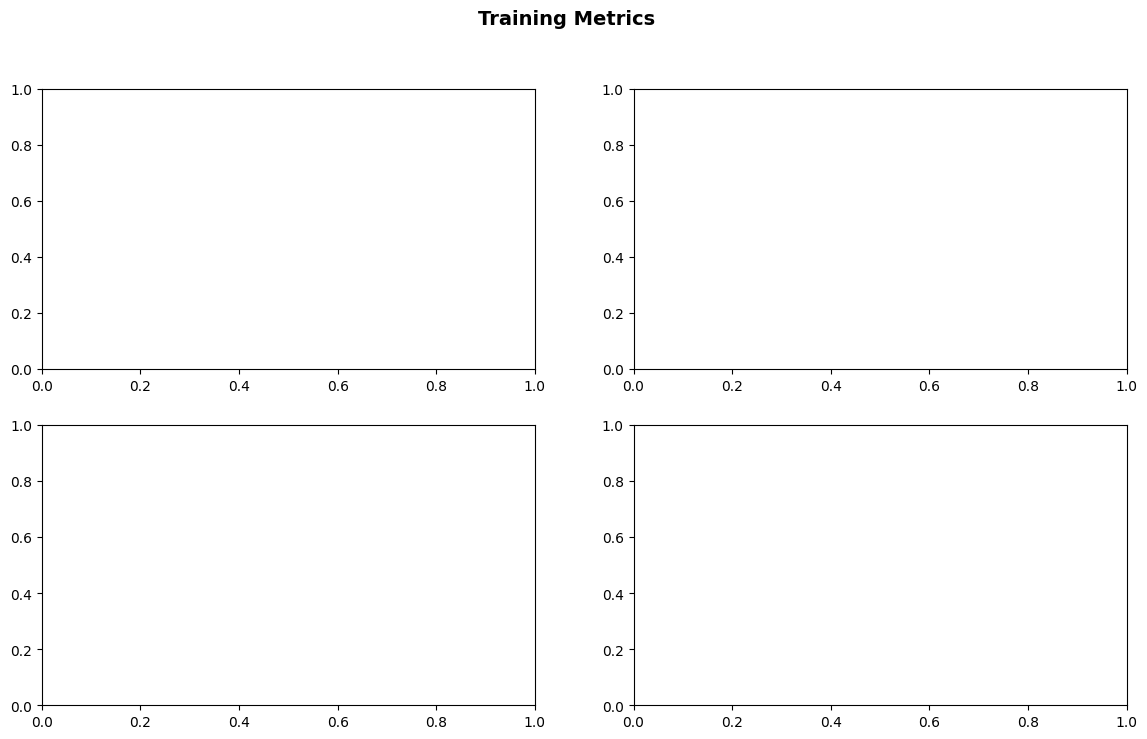

In [8]:
def smooth(values, window=20):
    """Rolling mean."""
    arr = np.array(values, dtype=float)
    return np.convolve(arr, np.ones(window) / window, mode='valid')


W = 20  # smoothing window

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Training Metrics", fontsize=14, fontweight="bold")

# ── Panel 1: Episode Return ──────────────────────────────────────────
ax = axes[0, 0]
for label, hist, color in [
    ("SARSA", sarsa_history, "steelblue"),
    ("REINFORCE", reinforce_history, "darkorange"),
]:
    raw = np.array(hist["episode_returns"])
    ax.plot(raw, alpha=0.15, color=color)
    ax.plot(range(W - 1, len(raw)), smooth(raw, W), label=label, color=color, linewidth=2)
ax.set_title("Episode Return")
ax.set_xlabel("Episode")
ax.set_ylabel("Return")
ax.legend()

# ── Panel 2: Collision Rate (rolling window) ─────────────────────────
ax = axes[0, 1]
for label, hist, color in [
    ("SARSA", sarsa_history, "steelblue"),
    ("REINFORCE", reinforce_history, "darkorange"),
]:
    raw = np.array(hist["collision_flags"], dtype=float) * 100
    ax.plot(range(W - 1, len(raw)), smooth(raw, W), label=label, color=color, linewidth=2)
ax.set_title(f"Collision Rate (rolling {W}-ep %)")
ax.set_xlabel("Episode")
ax.set_ylabel("Collision %")
ax.set_ylim(0, 100)
ax.legend()

# ── Panel 3: Huber Loss (SARSA only) ────────────────────────────────
ax = axes[1, 0]
raw = np.array(sarsa_history["huber_losses"])
ax.plot(raw, alpha=0.2, color="steelblue")
ax.plot(range(W - 1, len(raw)), smooth(raw, W), color="steelblue", linewidth=2, label="SARSA")
ax.set_title("SARSA — Mean Huber Loss per Episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Huber Loss")
ax.legend()

# ── Panel 4: Policy Entropy (REINFORCE only) ────────────────────────
ax = axes[1, 1]
raw = np.array(reinforce_history["entropies"])
ax.plot(raw, alpha=0.2, color="darkorange")
ax.plot(range(W - 1, len(raw)), smooth(raw, W), color="darkorange", linewidth=2, label="REINFORCE")
ax.set_title("REINFORCE — Mean Policy Entropy per Episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Entropy (nats)")
ax.legend()

plt.tight_layout()
plt.show()


---
## 7. Load Agents from Checkpoints

Run this cell **instead of training** if you already have saved checkpoints.  
It overwrites `sarsa_agent` and `reinforce_agent` with the saved weights so that all evaluation cells below work without retraining.

In [9]:
import os
import numpy as np
import torch

SAVE_DIR = "checkpoints"

# ── Re-create agent objects (identical hyperparams to training) ───────
sarsa_agent = SemiGradientSARSA(obs_dim=OBS_DIM, n_actions=N_ACTIONS)
sarsa_agent.W = np.load(os.path.join(SAVE_DIR, "sarsa_weights.npy"))
sarsa_agent.epsilon = 0.0  # greedy for evaluation
print(f"SARSA weights loaded  — shape: {sarsa_agent.W.shape}")

reinforce_agent = REINFORCE(obs_dim=OBS_DIM, n_actions=N_ACTIONS)
reinforce_agent.policy.load_state_dict(
    torch.load(os.path.join(SAVE_DIR, "reinforce_policy.pth"), map_location="cpu")
)
reinforce_agent.policy.eval()
print("REINFORCE policy loaded — ready for evaluation.")


SARSA weights loaded  — shape: (5, 50)
REINFORCE policy loaded — ready for evaluation.


---
## 7. Quantitative Evaluation

Greedy evaluation over multiple episodes. Metrics collected:

| Metric | Description |
|---|---|
| **Mean return** | Average episode return (± std) |
| **Collision rate** | % of episodes ending with a crash |
| **Mean episode length** | Average number of steps survived |
| **Mean speed** | Average `speed` reported by highway-env |
| **Mean Huber loss** | SARSA only — TD error quality |
| **Mean policy entropy** | REINFORCE only — policy confidence at evaluation time |

In [20]:
def evaluate_quantitative(agent_name, select_action_fn, n_episodes=30,
                           sarsa_agent_ref=None, reinforce_agent_ref=None):
    """
    Full quantitative evaluation of an agent.
    Returns a dict of metrics and prints a summary table.
    """
    env = make_env()
    all_returns, all_lengths, all_speeds = [], [], []
    all_collisions = []
    all_huber, all_entropy = [], []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        phi = flatten_obs(obs)
        done = truncated = False
        total_reward = 0.0
        steps = 0
        speeds = []
        collided = False
        ep_huber = []
        ep_entropy = []

        prev_phi = phi
        prev_action = select_action_fn(phi)

        while not (done or truncated):
            obs_next, reward, done, truncated, info = env.step(prev_action)
            phi_next = flatten_obs(obs_next)
            next_action = select_action_fn(phi_next)

            total_reward += reward
            steps += 1
            speeds.append(info.get("speed", float("nan")))

            if info.get("crashed", False):
                collided = True

            # SARSA: compute Huber loss on the greedy trajectory
            if sarsa_agent_ref is not None:
                q_cur = sarsa_agent_ref.W[prev_action] @ prev_phi
                if done or truncated:
                    td_err = reward - q_cur
                else:
                    q_nxt = sarsa_agent_ref.W[next_action] @ phi_next
                    td_err = reward + sarsa_agent_ref.gamma * q_nxt - q_cur
                ep_huber.append(sarsa_agent_ref.huber_loss(td_err))

            # REINFORCE: measure policy entropy
            if reinforce_agent_ref is not None:
                with torch.no_grad():
                    x = torch.from_numpy(phi_next).unsqueeze(0)
                    probs = reinforce_agent_ref.policy(x)
                    dist = torch.distributions.Categorical(probs)
                    ep_entropy.append(dist.entropy().item())

            prev_phi = phi_next
            prev_action = next_action

        all_returns.append(total_reward)
        all_lengths.append(steps)
        all_speeds.append(np.nanmean(speeds))
        all_collisions.append(int(collided))
        if ep_huber:
            all_huber.append(np.mean(ep_huber))
        if ep_entropy:
            all_entropy.append(np.mean(ep_entropy))

    env.close()

    metrics = {
        "mean_return":    np.mean(all_returns),
        "std_return":     np.std(all_returns),
        "collision_rate": np.mean(all_collisions) * 100,
        "mean_length":    np.mean(all_lengths),
        "mean_speed":     np.nanmean(all_speeds),
    }
    if all_huber:
        metrics["mean_huber_loss"] = np.mean(all_huber)
    if all_entropy:
        metrics["mean_entropy"] = np.mean(all_entropy)

    print(f"\n{'='*50}")
    print(f"  {agent_name:^46}  ")
    print(f"{'='*50}")
    print(f"  Mean return       : {metrics['mean_return']:+.4f} ± {metrics['std_return']:.4f}")
    print(f"  Collision rate    : {metrics['collision_rate']:.1f}%  ({int(np.sum(all_collisions))}/{n_episodes} episodes)")
    print(f"  Mean ep. length   : {metrics['mean_length']:.1f} steps")
    print(f"  Mean speed        : {metrics['mean_speed']:.2f} m/s")
    if "mean_huber_loss" in metrics:
        print(f"  Mean Huber loss   : {metrics['mean_huber_loss']:.6f}")
    if "mean_entropy" in metrics:
        print(f"  Mean policy entr. : {metrics['mean_entropy']:.4f} nats")
    print(f"{'='*50}\n")
    return metrics


# ── Run evaluations ──────────────────────────────────────────────────
N_EVAL = 50

sarsa_metrics = evaluate_quantitative(
    "SARSA (greedy)",
    lambda phi: sarsa_agent.select_action(phi, greedy=True),
    n_episodes=N_EVAL,
    sarsa_agent_ref=sarsa_agent,
)

reinforce_metrics = evaluate_quantitative(
    "REINFORCE (greedy)",
    reinforce_agent.select_action_greedy,
    n_episodes=N_EVAL,
    reinforce_agent_ref=reinforce_agent,
)

# Random baseline (no huber/entropy)
rand_env = make_env()
random_metrics = evaluate_quantitative(
    "Random agent (baseline)",
    lambda phi: rand_env.action_space.sample(),
    n_episodes=N_EVAL,
)
rand_env.close()



                  SARSA (greedy)                  
  Mean return       : +20.1000 ± 2.4818
  Collision rate    : 2.0%  (1/50 episodes)
  Mean ep. length   : 29.5 steps
  Mean speed        : 19.99 m/s
  Mean Huber loss   : 0.265992


                REINFORCE (greedy)                
  Mean return       : +16.1331 ± 6.2653
  Collision rate    : 64.0%  (32/50 episodes)
  Mean ep. length   : 21.9 steps
  Mean speed        : 23.31 m/s
  Mean policy entr. : 0.8323 nats


             Random agent (baseline)              
  Mean return       : +12.0907 ± 7.8618
  Collision rate    : 78.0%  (39/50 episodes)
  Mean ep. length   : 16.2 steps
  Mean speed        : 23.62 m/s



---
## 8. Metric Comparison Chart

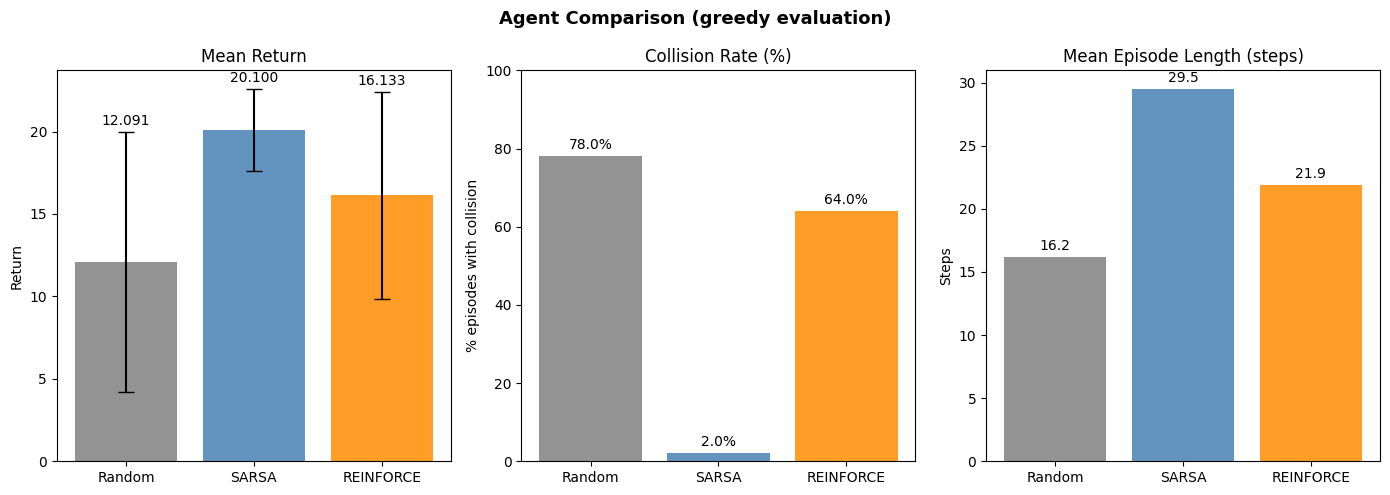

In [21]:
agents = ["Random", "SARSA", "REINFORCE"]
colors = ["gray", "steelblue", "darkorange"]
metrics_list = [random_metrics, sarsa_metrics, reinforce_metrics]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Agent Comparison (greedy evaluation)", fontsize=13, fontweight="bold")

# Return
ax = axes[0]
means = [m["mean_return"] for m in metrics_list]
stds  = [m["std_return"]  for m in metrics_list]
bars = ax.bar(agents, means, yerr=stds, color=colors, capsize=6, alpha=0.85)
ax.set_title("Mean Return")
ax.set_ylabel("Return")
ax.bar_label(bars, fmt="%.3f", padding=3)

# Collision rate
ax = axes[1]
cols = [m["collision_rate"] for m in metrics_list]
bars = ax.bar(agents, cols, color=colors, alpha=0.85)
ax.set_title("Collision Rate (%)")
ax.set_ylabel("% episodes with collision")
ax.set_ylim(0, 100)
ax.bar_label(bars, fmt="%.1f%%", padding=3)

# Mean episode length
ax = axes[2]
lengths = [m["mean_length"] for m in metrics_list]
bars = ax.bar(agents, lengths, color=colors, alpha=0.85)
ax.set_title("Mean Episode Length (steps)")
ax.set_ylabel("Steps")
ax.bar_label(bars, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()


In [ ]:
import os

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)

# Save SARSA weights
np.save(os.path.join(save_dir, "sarsa_weights.npy"), sarsa_agent.W)
print("SARSA weights saved.")

# Save REINFORCE policy network
torch.save(reinforce_agent.policy.state_dict(),
           os.path.join(save_dir, "reinforce_policy.pth"))
print("REINFORCE policy saved.")


SARSA weights saved.
REINFORCE policy saved.


In [ ]:
# ---- Load SARSA ----
loaded_sarsa = SemiGradientSARSA(obs_dim=OBS_DIM, n_actions=N_ACTIONS)
loaded_sarsa.W = np.load(os.path.join(save_dir, "sarsa_weights.npy"))

# ---- Load REINFORCE ----
loaded_reinforce = REINFORCE(obs_dim=OBS_DIM, n_actions=N_ACTIONS, device=DEVICE)
loaded_reinforce.policy.load_state_dict(
    torch.load(os.path.join(save_dir, "reinforce_policy.pth"), map_location=DEVICE)
)
loaded_reinforce.policy.eval()
print("Agents loaded successfully.")

Agents loaded successfully.


---
## 9. Qualitative Evaluation — Video Recording

Record one episode per agent and display the video inline.  
`gymnasium`'s `RecordVideo` wrapper saves an `.mp4` file; we then render it with an HTML5 video tag.

In [17]:
%pip install "gymnasium[other]"

  Using cached moviepy-2.2.1-py3-none-any.whl.metadata (6.9 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached imageio_ffmpeg-0.6.0-py3-none-win_amd64.whl.metadata (1.5 kB)
  Using cached proglog-0.1.12-py3-none-any.whl.metadata (794 bytes)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached pillow-11.3.0-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.0 MB ? eta -:--:--
   --- ------------------------------------ 0.5/7.0 MB 1.9 MB/s eta 0:00:04
   ---- ----------------------------------- 0.8/7.0 MB 1.3 MB/s eta 0:00:05
   ------- -------------------------------- 1.3/7.0 MB 1.6 MB/s eta 0:00:04
   ---------- ---------

  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display
import base64

VIDEO_DIR = "videos"
os.makedirs(VIDEO_DIR, exist_ok=True)


def record_episode(agent_name: str, select_action_fn, video_dir: str = VIDEO_DIR, episode_idx: int = 0):
    """
    Record one greedy episode and return (video_path, speed_history).
    speed_history is a list of per-step speeds (m/s) from info['speed'].
    """
    out_dir = os.path.join(video_dir, agent_name.lower().replace(" ", "_"))
    os.makedirs(out_dir, exist_ok=True)

    base_env = gym.make("highway-v0", render_mode="rgb_array")
    base_env.unwrapped.configure(SHARED_CORE_CONFIG)
    base_env.reset()

    env = RecordVideo(
        base_env,
        video_folder=out_dir,
        episode_trigger=lambda ep: True,
        name_prefix=f"{agent_name}-ep{episode_idx:02d}",
        disable_logger=True,
    )

    obs, _ = env.reset()
    phi = flatten_obs(obs)
    done = truncated = False
    total_reward = 0.0
    speed_history = []

    while not (done or truncated):
        action = select_action_fn(phi)
        obs, reward, done, truncated, info = env.step(action)
        phi = flatten_obs(obs)
        total_reward += reward
        speed_history.append(info.get("speed", float("nan")))

    env.close()
    print(f"[{agent_name}] Episode {episode_idx + 1:2d} | "
          f"Return: {total_reward:.3f} | "
          f"Mean speed: {np.nanmean(speed_history):.2f} m/s | "
          f"Min: {np.nanmin(speed_history):.2f} | Max: {np.nanmax(speed_history):.2f}")

    mp4_files = sorted(
        [f for f in os.listdir(out_dir) if f.endswith(".mp4")],
        key=lambda f: os.path.getmtime(os.path.join(out_dir, f)),
    )
    path = os.path.join(out_dir, mp4_files[-1]) if mp4_files else None
    return path, speed_history


def show_video(path: str, title: str = "", speed_history: list = None):
    """Display an mp4 file inline in the notebook, optionally with a speed plot."""
    if path is None or not os.path.exists(path):
        print("No video found.")
        return
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    html = f"""
    <h3>{title}</h3>
    <video width="640" controls autoplay loop>
        <source src="data:video/mp4;base64,{data}" type="video/mp4">
    </video>"""
    display(HTML(html))

    if speed_history:
        fig, ax = plt.subplots(figsize=(8, 2))
        ax.plot(speed_history, color="steelblue")
        ax.set_xlabel("Step")
        ax.set_ylabel("Speed (m/s)")
        ax.set_title(f"{title} — Speed over time")
        plt.tight_layout()
        plt.show()


# ── Record 20 episodes per agent ─────────────────────────────────────
N_VIDEOS = 20

sarsa_results = [
    record_episode("SARSA", lambda phi: sarsa_agent.select_action(phi, greedy=True), episode_idx=i)
    for i in range(N_VIDEOS)
]
sarsa_videos, sarsa_speeds = zip(*sarsa_results)

reinforce_results = [
    record_episode("REINFORCE", reinforce_agent.select_action_greedy, episode_idx=i)
    for i in range(N_VIDEOS)
]
reinforce_videos, reinforce_speeds = zip(*reinforce_results)

random_env_vid = make_env()
random_results = [
    record_episode("Random", lambda phi: random_env_vid.action_space.sample(), episode_idx=i)
    for i in range(N_VIDEOS)
]
random_env_vid.close()
random_videos, random_speeds = zip(*random_results)


[SARSA] Episode  1 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode  2 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode  3 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode  4 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode  5 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode  6 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode  7 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode  8 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode  9 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode 10 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode 11 | Return: 20.455 | Mean speed: 20.03 m/s | Min: 20.00 | Max: 20.85
[SARSA] Episode 12 | Return: 20.455 | Mean speed: 20.0

In [ ]:
# ── Display videos inline with speed plots ───────────────────────────
for i, (path, speeds) in enumerate(zip(sarsa_videos, sarsa_speeds)):
    show_video(path, title=f"SARSA — Greedy Episode {i + 1}", speed_history=speeds)

for i, (path, speeds) in enumerate(zip(reinforce_videos, reinforce_speeds)):
    show_video(path, title=f"REINFORCE — Greedy Episode {i + 1}", speed_history=speeds)

for i, (path, speeds) in enumerate(zip(random_videos, random_speeds)):
    show_video(path, title=f"Random Agent — Baseline Episode {i + 1}", speed_history=speeds)
